In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv


# Loading the Datasets

In [2]:
train = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/train.csv")
test = pd.read_csv("/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/test.csv") 

# Shape of Datasets

In [3]:
print("Training data shape:", train.shape)
print("Test data shape:", test.shape)

Training data shape: (40000, 12)
Test data shape: (10000, 11)



> Two different methods are used below to find dataypes of training and test data respectively:
> 
> (A) Using Dataframe
> 
> (B) Using .info()


# Datatypes of TrainingData_Columns

In [4]:
datatypes = pd.DataFrame({
    'Column Name': train.columns,
    'Data type': train.dtypes.values
})
datatypes

,Column Name,Data type
0,id,int64
1,airline,object
2,flight,object
3,source,object
4,departure,object
5,stops,object
6,arrival,object
7,destination,object
8,class,object
9,duration,float64


# Datatypes of TestData_Columns

In [5]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   airline      9452 non-null   object 
 2   flight       10000 non-null  object 
 3   source       10000 non-null  object 
 4   departure    9080 non-null   object 
 5   stops        9349 non-null   object 
 6   arrival      10000 non-null  object 
 7   destination  10000 non-null  object 
 8   class        10000 non-null  object 
 9   duration     9418 non-null   float64
 10  days_left    9304 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB
None


In [6]:
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   airline      9452 non-null   object 
 2   flight       10000 non-null  object 
 3   source       10000 non-null  object 
 4   departure    9080 non-null   object 
 5   stops        9349 non-null   object 
 6   arrival      10000 non-null  object 
 7   destination  10000 non-null  object 
 8   class        10000 non-null  object 
 9   duration     9418 non-null   float64
 10  days_left    9304 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB
None


> Above we can observe that 'Price' Column with Datatype 'int64' is not there in Test Data however it is present in Training Data.

# Descriptive Statistics of Numerical Columns

In [7]:
stats = train.describe()
stats

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


# Identify and Handle the Missing Values 

**Identyfying Missing Values:**

In [8]:
missing_val = train.isnull().sum()
missing_val = missing_val[missing_val > 0]
missing_val

airline      4613
departure    4792
stops        2319
duration     3013
days_left    4438
dtype: int64

**Handling:**

* For numerical values - imputing with median
* For categorical values - imputing with mode

In [9]:
train_cleansed = train.copy()
for column in missing_val.index:
    if train[column].dtype in ['float64', 'int64']:
        train_cleansed[column] = train[column].fillna(train[column].median())
    else:
        train_cleansed[column] = train[column].fillna(train[column].mode()[0])

print(train_cleansed.isnull().sum())

id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64


> Above are the missing values in training data after proper handling.

# Identify and Handle Duplicates

**Identifying Duplicates:**

In [10]:
train_cleansed.duplicated().sum()

0

> The given training data do not have duplicates but still the method given below can be used to handle duplicates in datasets. 

**Handling:**

In [11]:
train_cleansed=train_cleansed.drop_duplicates()

# To check whether data got duplicates. 
train_cleansed.duplicated().sum()

0

# Identify and Handle Outliers

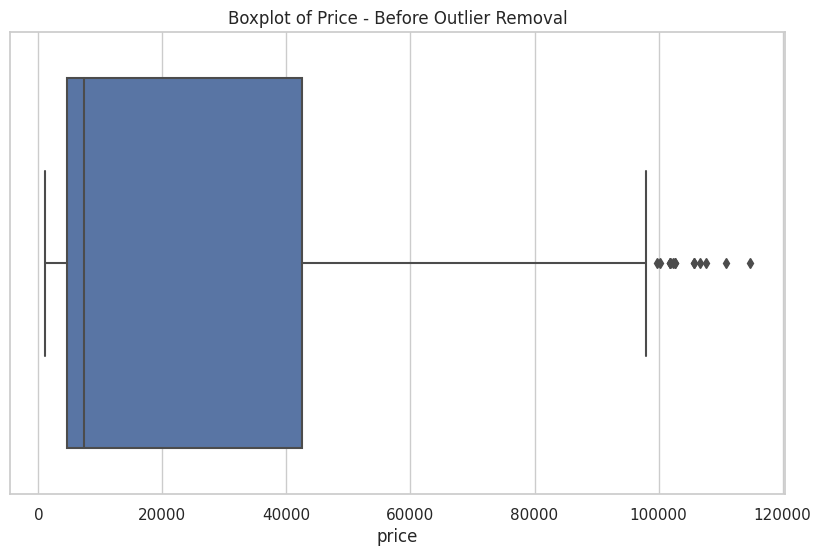

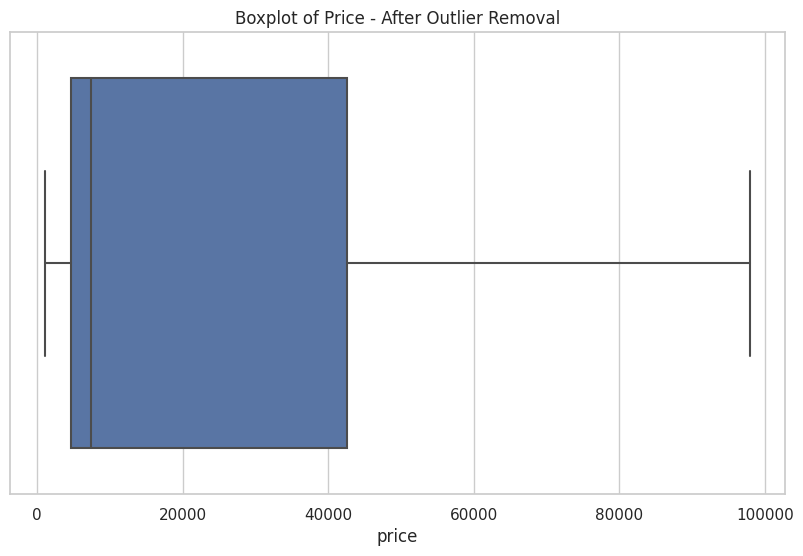

Original shape: (40000, 12)
Filtered shape: (39986, 12)


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Before outlier removal
sns.boxplot(x=train['price'])
plt.title("Boxplot of Price - Before Outlier Removal")
plt.show()

# After outlier removal (using IQR method)
Q1 = train_cleansed['price'].quantile(0.25)
Q3 = train_cleansed['price'].quantile(0.75)
IQR = Q3 - Q1
train_filtered = train_cleansed[(train_cleansed['price'] >= Q1 - 1.5 * IQR) & (train_cleansed['price'] <= Q3 + 1.5 * IQR)]

sns.boxplot(x=train_filtered['price'])
plt.title("Boxplot of Price - After Outlier Removal")
plt.show()


print(f"Original shape: {train.shape}")
print(f"Filtered shape: {train_filtered.shape}")

**Explanation for Droping Outliers:**
* Skew the mean and standard deviation.
* Hurt regression models (especially Linear Regression).
* Reduce model accuracy.

# Data Visualizations

**1) Average Price by Airlines**

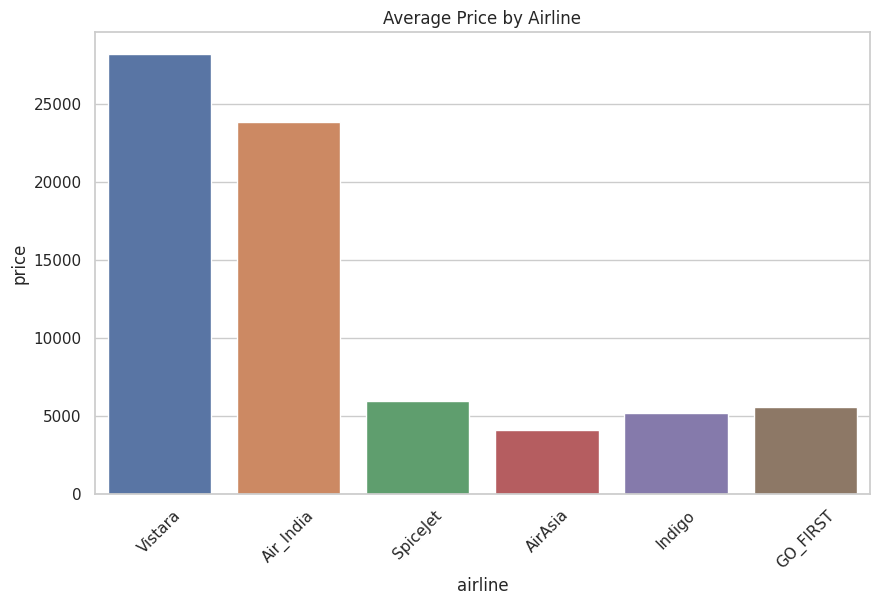

In [13]:
sns.barplot(x='airline', y='price', data=train_cleansed, estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title("Average Price by Airline")
plt.show()

> It can be observed that Airlines like Air India and Vistara have higher average prices whereas Spicejet, Indigo, GO_FIRST and AirAsia airlines provide cheaper flights. 

**2) Distributon of Ticket Price**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


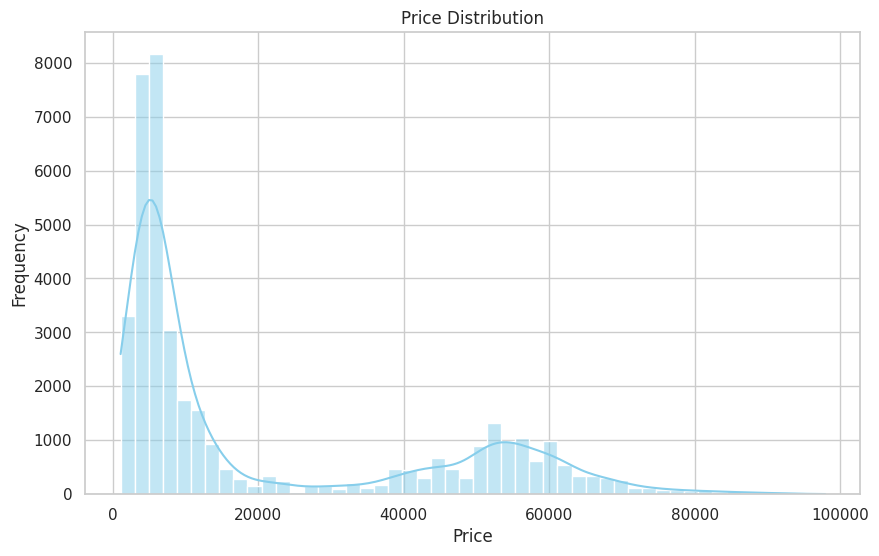

In [14]:
sns.histplot(train_filtered['price'], bins=50, kde=True, color='skyblue')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

> Here, we can visualize the peak around the lower price range suggesting that the most common prices are in this region. A right-skewed distribution can be observed however a few higher prices are still present in between.

**3) Correlation: Price vs Duration**

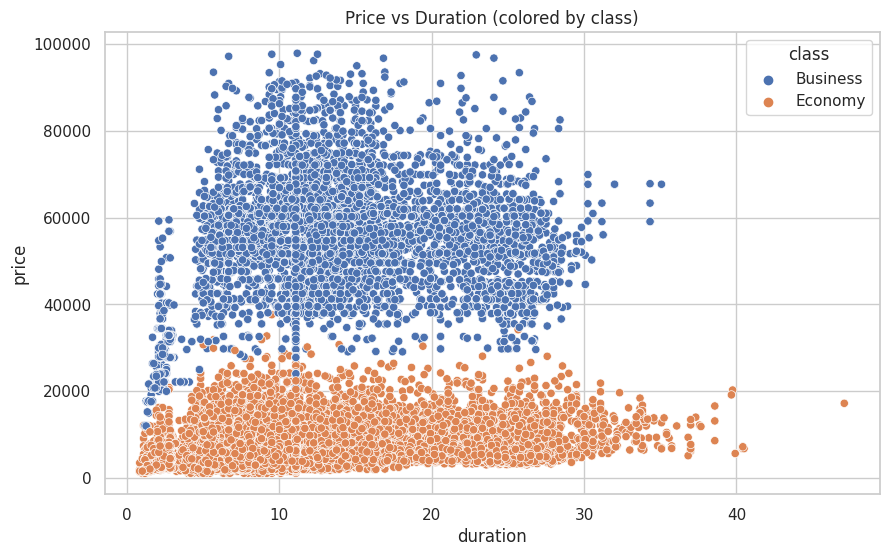

In [15]:
sns.scatterplot(x='duration', y='price', hue='class', data=train_filtered)
plt.title("Price vs Duration (colored by class)")
plt.show()

> A positive Correlation is observed as Duration increases, Price also increases. Business class prices are significantly higher.
>
> Horizontal clustering shows multiple flights with similar durations but different prices due to class.
> 
> Vertical stripes at certain durations indicating popular flight durations. 

# Scaling and Encoding

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

# Features & Target
features_to_drop = ['id', 'price']
X = train_filtered.drop(columns=features_to_drop)
y = train_filtered['price']

# Test Set
X_test = test.drop(columns=['id'])

# Feature Types
numerical_cols = ['duration', 'days_left']
categorical_cols = ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']

# Column Transformer
transformer = make_column_transformer(
    (StandardScaler(), numerical_cols),# Numerical Feature Scaling with StandardScaler()
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols),# Categorical Feature Encoding with OneHotEncoder()
    remainder='drop'
)

# Pipeline
preprocessing_pipeline = make_pipeline(transformer)

# Fit and Transform
X_processed = preprocessing_pipeline.fit_transform(X)
X_test_processed = preprocessing_pipeline.transform(X_test)

# Extract feature names after transformation
encoder = preprocessing_pipeline.named_steps['columntransformer']
feature_names = encoder.get_feature_names_out()

# Create final DataFrames
X_final = pd.DataFrame(X_processed.toarray(), columns=feature_names)
X_test_final = pd.DataFrame(X_test_processed.toarray(), columns=feature_names)

# Split data
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42)

**Explanation for Scaling:**

> Numerical features like duration and days_left can have very different ranges so in order to ensure that
all features contribute equally to the models like KNN, SVM, Logistic Regression, scaling is used. It centers each feature around zero mean and scales it to unit variance. 

**Explanation for Encoding:**

> ML models require numerical input. Strings like "IndiGo" or "New Delhi" are not interpretable numerically. So to convert the string data of each unique category into a separate binary column, we use Encoders like OneHotEncoder.

# Model Building & Evaluation

In [17]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Optional: XGBoost (install via pip install xgboost if not available)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed, skipping XGBRegressor.")

# Define all models(M)
models = {
    "Linear Regression": LinearRegression(),# M1
    "Ridge Regression": Ridge(alpha=1.0),# M2
    "Lasso Regression": Lasso(alpha=0.1, max_iter=5000),# M3
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),# M4
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),# M5
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)# M6
}

# Add XGBoost if available
if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)# M7

# Evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    
    results.append((name, round(rmse, 2), round(r2, 4)))

# Display results
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R² Score"])
print(results_df)

               Model          RMSE      R² Score
0  Linear Regression  3.102419e+14 -1.875004e+20
1   Ridge Regression  6.405470e+03  9.201000e-01
2   Lasso Regression  6.410820e+03  9.199000e-01
3      Decision Tree  5.370250e+03  9.438000e-01
4      Random Forest  4.735790e+03  9.563000e-01
5  Gradient Boosting  4.602500e+03  9.587000e-01
6            XGBoost  4.619860e+03  9.584000e-01


# Hyperparameter Tuning

**XGBoost**

In [18]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0  # suppress training logs
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

print("XGBoost RMSE:", mean_squared_error(y_val, y_pred_xgb, squared=False))
print("XGBoost R² Score:", r2_score(y_val, y_pred_xgb))

XGBoost RMSE: 5112.7818963659865
XGBoost R² Score: 0.9490767892158398


**Gradient Boosting**

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_val)

print("Gradient Boosting RMSE:", mean_squared_error(y_val, y_pred_gbr, squared=False))
print("Gradient Boosting R² Score:", r2_score(y_val, y_pred_gbr))

Gradient Boosting RMSE: 5080.115850610762
Gradient Boosting R² Score: 0.9497254168967716


**Random Forest**

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

print("Random Forest RMSE:", mean_squared_error(y_val, y_pred_rf, squared=False))
print("Random Forest R² Score:", r2_score(y_val, y_pred_rf))

Random Forest RMSE: 4017.3841969779896
Random Forest R² Score: 0.9685596060627845


***Comparison of Top 3 Models***
> 
* **Random Forest**
  >RMSE: 4017.3842
  >
  >R^2: 0.9685
* **Gradeint Boosting**
  >RMSE: 5080.1158
  >
  >R^2: 0.9497
* **XGBoost**
  >RMSE: 5112.7818
  >
  >R^2: 0.9490
  >
***Best Model: Random Forest***

# Refit Data on Best Model

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Refit on full training data for best generalization
rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_final, y)  # X_df: full preprocessed train features; y: target variable


RandomForestRegressor(n_jobs=-1, random_state=42)

# Predictions on Test Data

In [22]:
from sklearn.impute import SimpleImputer

# Impute missing values in test set
imputer = SimpleImputer(strategy='mean')  # or 'median' for robust handling
X_test_final_imputed = imputer.fit_transform(X_test_final)

# Now make predictions
rf_test_preds = rf_final.predict(X_test_final_imputed)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# File Submission

In [23]:
# Load sample submission
sample_submission = pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-1/sample_submission.csv')

# Create submission file
submission = pd.DataFrame({
    'id': sample_submission['id'],
    'price': rf_test_preds
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("saved successfully!")

saved successfully!


# Reading Submitted File

In [24]:
f=pd.read_csv("/kaggle/working/submission.csv")
print(f)

        id       price
0        0   4540.5400
1        1  12212.4700
2        2   3824.8800
3        3  61329.9325
4        4  49950.5200
...    ...         ...
9995  9995   4513.2100
9996  9996   8417.2825
9997  9997  86527.2800
9998  9998  56590.0000
9999  9999  58873.3400

[10000 rows x 2 columns]
